<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/pca_practice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

digit_recognizer_path = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [ ]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [ ]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import matplotlib.pyplot as plt

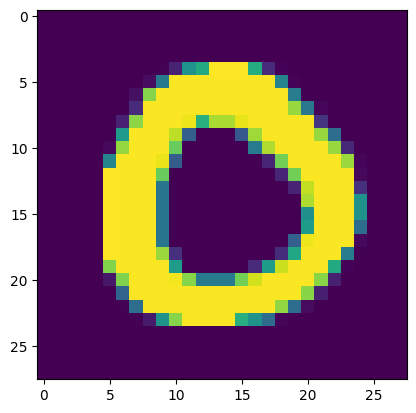

In [ ]:
plt.imshow(df.iloc[4,1:].values.reshape(28,28))
#plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

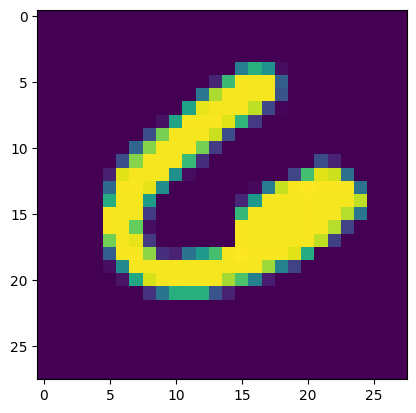

In [ ]:
plt.imshow(df.iloc[1200,1:].values.reshape(28,28))


In [ ]:
x = df.iloc[:,1:]
y =df.iloc[:,0]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train , x_test ,y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape)
df.shape

(33600, 784)


(42000, 785)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time() - start)

9.49761438369751


In [ ]:
from sklearn.metrics  import accuracy_score

In [ ]:
y_pred = knn.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9648809523809524


In [ ]:
from sklearn.preprocessing import StandardScaler

sklearn.preprocessing._data.StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
 x_train_trf = scaler.fit_transform(x_train)
x_test_trf = scaler.transform(x_test)


In [ ]:
# PCA
from sklearn.decomposition import PCA


In [ ]:
pca = PCA(n_components=200)

In [ ]:
x_train_trf =  pca.fit_transform(x_train_trf)
x_test_trf =pca.transform(x_test_trf)

In [ ]:
knn.fit(x_train_trf ,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(x_test_trf)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.9507142857142857


In [ ]:
for i in range(200,785):
    pca = PCA(n_components=i)
    x_train_trf = pca.fit_transform(x_train)
    x_test_trf = pca.transform(x_test)

    knn = KNeighborsClassifier()

    knn.fit(x_train_trf,y_train)

    y_pred = knn.predict(x_test_trf)

    print(i," ",accuracy_score(y_test,y_pred))


In [ ]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=x_train_trf[:,0],
                 y=x_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [ ]:
pca = PCA(n_components =3)
X_train_trf = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

In [ ]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [ ]:
pca.explained_variance_
# Eigen values

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [ ]:
pca.components_.shape
# Eigen vectors


(3, 3)

In [ ]:
pca.explained_variance_ratio_

array([0.42342443, 0.30895761, 0.26761797])

In [ ]:
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [ ]:
pca.explained_variance_.shape

(3,)

In [ ]:
pca.components_.shape

(3, 3)

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

array([0.42342443, 0.73238203, 1.        ])

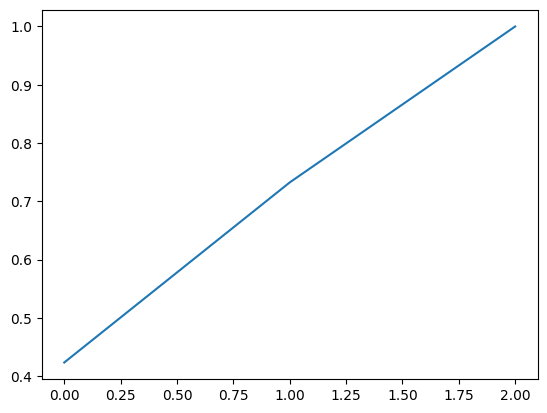

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))